
--- PERFORMANCE: SÍNTOMAS SAP (Gestión) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     21022

    accuracy                           1.00     21022
   macro avg       1.00      1.00      1.00     21022
weighted avg       1.00      1.00      1.00     21022


--- PERFORMANCE: SÍNTOMAS SCADA (Física) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19520
           1       1.00      1.00      1.00      1502

    accuracy                           1.00     21022
   macro avg       1.00      1.00      1.00     21022
weighted avg       1.00      1.00      1.00     21022



c:\Users\braya\Documents\TFM_UCM_Enagas\tfm_enagas\venv_tfm_enagas\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


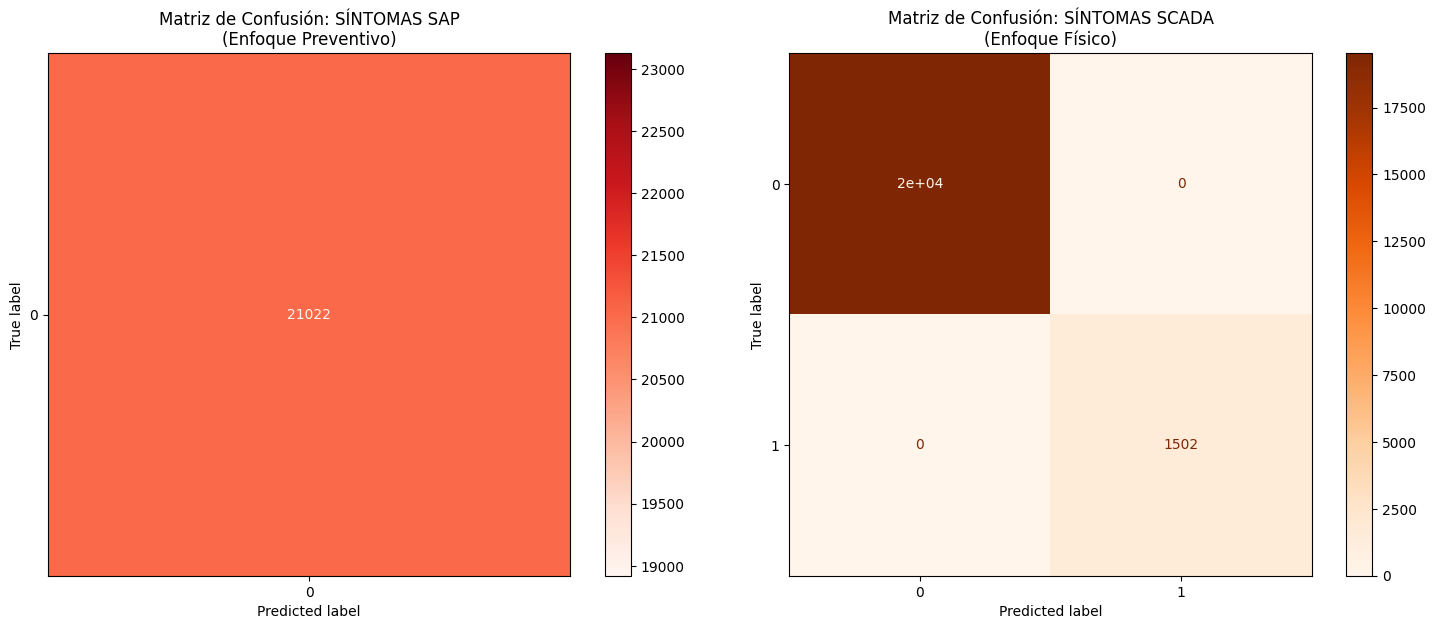

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# 1. CARGA Y PREPARACIÓN
df = pd.read_csv(r'C:\Users\braya\Documents\TFM_UCM_Enagas\tfm_enagas\data\processed\df_modelado_sintomas.csv', index_col='datetime', parse_dates=True)
df = df.fillna(0) # Limpiar el primer delta_presion que suele ser NaN

# Definir variables predictoras (X) - Solo Línea A
features = ['presion_in_A', 'temperatura_in_A', 'caudal_bruto_A', 
            'caudal_nominal_A', 'caudal_min_diario_A', 'caudal_max_diario_A', 'delta_presion_temp']

X = df[features]

# Split CRONOLÓGICO (80% entrenamiento, 20% prueba)
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]

# --- FUNCIÓN PARA ENTRENAR Y EVALUAR ---
def entrenar_modelo_sintomas(target_name, titulo):
    y = df[target_name]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    
    # Modelo con balanceo de peso (vital para detectar síntomas escasos)
    model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Reporte
    print(f"\n--- PERFORMANCE: {titulo} ---")
    print(classification_report(y_test, y_pred))
    
    return y_test, y_pred, model

# 2. MODELO SAP (is_anomaly)
y_test_sap, y_pred_sap, model_sap = entrenar_modelo_sintomas('is_anomaly', 'SÍNTOMAS SAP (Gestión)')

# 3. MODELO SCADA (is_scada_anomaly)
y_test_scada, y_pred_scada, model_scada = entrenar_modelo_sintomas('is_scada_anomaly', 'SÍNTOMAS SCADA (Física)')

# 4. COMPARACIÓN VISUAL (Matrices de Confusión)
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

ConfusionMatrixDisplay.from_predictions(y_test_sap, y_pred_sap, ax=ax[0], cmap='Reds')
ax[0].set_title('Matriz de Confusión: SÍNTOMAS SAP\n(Enfoque Preventivo)')

ConfusionMatrixDisplay.from_predictions(y_test_scada, y_pred_scada, ax=ax[1], cmap='Oranges')
ax[1].set_title('Matriz de Confusión: SÍNTOMAS SCADA\n(Enfoque Físico)')

plt.tight_layout()
plt.show()